# Two-layer diagnostics: savings metric fix + phase-2 transient characterization

Follow-up to `two_layer_consolidation.ipynb`, per Jasper's message relayed from the Claude
web chat (2026-07-18):

1. The original "savings" check (steps to re-cross `w_fast>=1.5`) was contaminated —
   `w_fast[0]` never dropped below 1.5 during phases 2-3, so "0 steps" measured residual
   elevation, not relearning speed. Fix: compare the **slope** of pattern 0's reacquisition
   curve in phase 4 against a genuine cold-start climb, not an absolute threshold crossing.
2. The phase-2 transient (56.6% misretrieval to pattern 0, vs 13.6% in phase 3) needs to be
   **measured**, not fixed yet — is it a fast-decaying transient or does it persist through
   most of the phase? Does its width scale with phase length or stay roughly constant in
   absolute steps?

Both are measurement tasks. No parameter tuning in this notebook.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
torch.manual_seed(42)
n_patterns = 5
dim = 64

X = torch.randn(n_patterns, dim, device=device)
X = F.normalize(X, dim=1)

## Two-layer mechanism (unchanged from the corrected `two_layer_consolidation.ipynb`)

Same saturating-headroom fix Jasper proposed and we validated: `w_char` growth shrinks
toward zero as it approaches `w_char_max`, staying fully inside the retrieval softmax.

In [3]:
decay_fast = 0.02
increment_fast = 0.1
decay_char = 0.0005
consolidation_rate = 0.01
char_weight = 1.0
w_char_max = 10.0

def update_two_layer(w_fast, w_char, retrieval_weights):
    w_fast = w_fast + decay_fast * (1 - w_fast) + increment_fast * retrieval_weights
    headroom = (w_char_max - w_char).clamp(min=0) / w_char_max
    w_char = w_char + decay_char * (1 - w_char) + consolidation_rate * (w_fast - 1).clamp(min=0) * headroom
    return w_fast, w_char

def retrieve_two_layer(query, X, w_fast, w_char, beta=4.0):
    similarities = X @ query
    biased = beta * similarities + torch.log(w_fast) + char_weight * torch.log(w_char)
    weights = F.softmax(biased, dim=0)
    retrieved = X.T @ weights
    return retrieved, weights

In [4]:
def run_two_layer_experiment(phase_len, phase_patterns, seed=0, dominant_prob=0.7):
    """phase_patterns: list of dominant-pattern index per phase, e.g. [0,1,2,0,3]."""
    n_phases = len(phase_patterns)
    n_steps = phase_len * n_phases

    w_fast = torch.ones(n_patterns, device=device)
    w_char = torch.ones(n_patterns, device=device)
    fast_history = torch.zeros(n_steps, n_patterns)
    char_history = torch.zeros(n_steps, n_patterns)
    queried_idx_history = torch.zeros(n_steps, dtype=torch.long)
    won_idx_history = torch.zeros(n_steps, dtype=torch.long)

    minor_prob = (1 - dominant_prob) / (n_patterns - 1)

    torch.manual_seed(seed)
    for step in range(n_steps):
        phase = step // phase_len
        dom = phase_patterns[phase]
        probs = torch.full((n_patterns,), minor_prob)
        probs[dom] = dominant_prob

        idx = torch.multinomial(probs, 1).item()
        query = F.normalize(X[idx] + torch.randn(dim, device=device) * 0.3, dim=0)

        retrieved, retrieval_weights = retrieve_two_layer(query, X, w_fast, w_char, beta=4.0)
        w_fast, w_char = update_two_layer(w_fast, w_char, retrieval_weights)

        fast_history[step] = w_fast
        char_history[step] = w_char
        queried_idx_history[step] = idx
        won_idx_history[step] = retrieval_weights.argmax()

    phase_bounds = [i * phase_len for i in range(n_phases + 1)]
    return {
        "fast": fast_history, "char": char_history,
        "queried": queried_idx_history, "won": won_idx_history,
        "phase_bounds": phase_bounds, "phase_patterns": phase_patterns,
        "phase_len": phase_len,
    }

## Main run: 5 phases — pattern 0, 1, 2, pattern 0 again (return), pattern 3 (first-ever dominance)

Phase 5 (pattern 3 dominant) is new: it gives a genuine cross-pattern cold-start control —
pattern 3 has never been dominant before, so its climb here is a true blank-slate reacquisition
curve, structurally matched (same 70% dominance probability, same phase length) to both
pattern 0's original phase-1 climb and its phase-4 return climb.

In [5]:
run = run_two_layer_experiment(phase_len=400, phase_patterns=[0, 1, 2, 0, 3], seed=0)
fast_history, char_history = run["fast"], run["char"]
phase_bounds = run["phase_bounds"]
print("Final w_fast:", fast_history[-1])
print("Final w_char:", char_history[-1])

Final w_fast: tensor([1.7128, 1.7331, 1.5558, 3.7147, 1.2837])
Final w_char: tensor([7.9532, 6.2345, 6.1958, 6.2645, 3.8202])


## Task 1 — Savings via slope comparison, not threshold crossing

Three candidate curves, all under identical 70%-dominance conditions:
- **Phase 1, pattern 0**: true cold start (w starts at baseline 1.0, never touched before).
- **Phase 4, pattern 0**: return (w starts at whatever residual it decayed to after phases 2-3).
- **Phase 5, pattern 3**: cross-pattern cold start (never dominant before, only minor
  incidental exposure over the preceding 1600 steps) — controls for pattern-0-specific
  idiosyncrasies (e.g. its particular random vector) confounding the phase-1-vs-4 comparison.

Metric: since the three curves have different starting points and different net increases,
an absolute threshold is exactly the trap we're fixing. Instead: (a) steps to reach 90% of
that curve's own net increase (peak-in-phase minus phase-start value) — normalized climb
speed; (b) linear-regression slope over the first 50 steps of the phase — raw initial rate.

In [6]:
def climb_stats(fast_history, pattern_idx, phase_start, phase_end, label):
    segment = fast_history[phase_start:phase_end, pattern_idx].numpy()
    start_val = segment[0]
    peak_val = segment.max()
    net_increase = peak_val - start_val

    # smooth lightly to avoid noise-triggered early crossings
    kernel = np.ones(10) / 10
    smoothed = np.convolve(segment, kernel, mode="valid")
    threshold = start_val + 0.9 * net_increase
    hits = np.nonzero(smoothed >= threshold)[0]
    steps_to_90pct = int(hits[0]) if len(hits) > 0 else None

    x = np.arange(50)
    slope, intercept = np.polyfit(x, segment[:50], 1)

    print(f"{label}: start={start_val:.3f} peak={peak_val:.3f} net_increase={net_increase:.3f} "
          f"steps_to_90%={steps_to_90pct} initial_slope(50 steps)={slope:.4f}")
    return {"start": start_val, "peak": peak_val, "net_increase": net_increase,
            "steps_to_90pct": steps_to_90pct, "slope": slope, "segment": segment}

pb = phase_bounds
r_phase1 = climb_stats(fast_history, 0, pb[0], pb[1], "Phase 1, pattern 0 (true cold start)")
r_phase4 = climb_stats(fast_history, 0, pb[3], pb[4], "Phase 4, pattern 0 (return)")
r_phase5 = climb_stats(fast_history, 3, pb[4], pb[5], "Phase 5, pattern 3 (cross-pattern cold start)")

Phase 1, pattern 0 (true cold start): start=1.015 peak=5.271 net_increase=4.256 steps_to_90%=209 initial_slope(50 steps)=0.0360
Phase 4, pattern 0 (return): start=2.012 peak=4.539 net_increase=2.527 steps_to_90%=175 initial_slope(50 steps)=0.0206
Phase 5, pattern 3 (cross-pattern cold start): start=1.326 peak=3.750 net_increase=2.424 steps_to_90%=308 initial_slope(50 steps)=0.0118


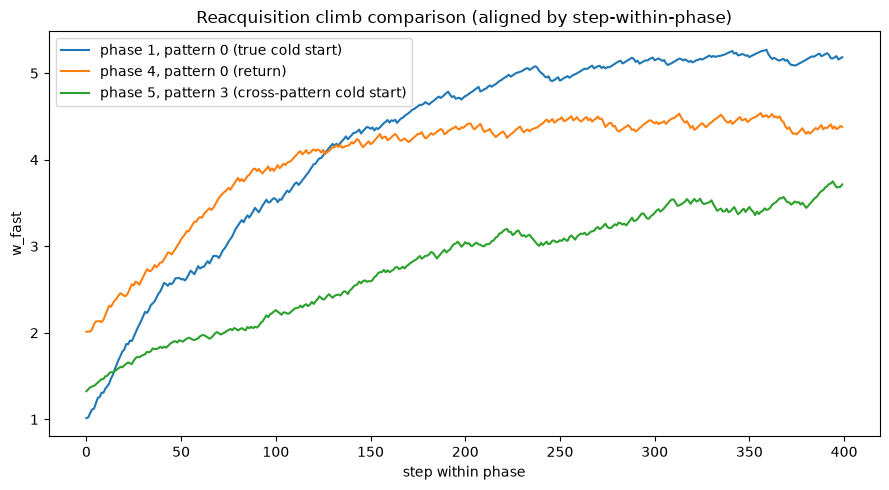

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(r_phase1["segment"], label="phase 1, pattern 0 (true cold start)")
plt.plot(r_phase4["segment"], label="phase 4, pattern 0 (return)")
plt.plot(r_phase5["segment"], label="phase 5, pattern 3 (cross-pattern cold start)")
plt.xlabel("step within phase")
plt.ylabel("w_fast")
plt.title("Reacquisition climb comparison (aligned by step-within-phase)")
plt.legend()
plt.tight_layout()
plt.savefig("savings_comparison.png", dpi=100)
plt.show()

In [8]:
print("Savings verdict (phase 4 vs both cold-start baselines):")
print(f"  steps_to_90%:  phase1={r_phase1['steps_to_90pct']}  phase4={r_phase4['steps_to_90pct']}  phase5={r_phase5['steps_to_90pct']}")
print(f"  initial_slope: phase1={r_phase1['slope']:.4f}  phase4={r_phase4['slope']:.4f}  phase5={r_phase5['slope']:.4f}")

faster_than_own_cold_start = (r_phase4['steps_to_90pct'] is not None and r_phase1['steps_to_90pct'] is not None
                               and r_phase4['steps_to_90pct'] < r_phase1['steps_to_90pct'])
faster_than_cross_pattern = (r_phase4['steps_to_90pct'] is not None and r_phase5['steps_to_90pct'] is not None
                              and r_phase4['steps_to_90pct'] < r_phase5['steps_to_90pct'])
print(f"  phase4 reaches 90% faster than phase1 (own cold start): {faster_than_own_cold_start}")
print(f"  phase4 reaches 90% faster than phase5 (cross-pattern cold start): {faster_than_cross_pattern}")

Savings verdict (phase 4 vs both cold-start baselines):
  steps_to_90%:  phase1=209  phase4=175  phase5=308
  initial_slope: phase1=0.0360  phase4=0.0206  phase5=0.0118
  phase4 reaches 90% faster than phase1 (own cold start): True
  phase4 reaches 90% faster than phase5 (cross-pattern cold start): True


## Task 2 — Phase-2 transient characterization (measurement only, no fix)

Windowed misretrieval rate: rolling-window fraction of steps where the retrieval winner is
pattern 0 despite pattern 0 not being the queried pattern. Computed as a function of
step-within-phase, for phase 2 (where the transient is large) and phase 3 (where it's much
smaller) for contrast.

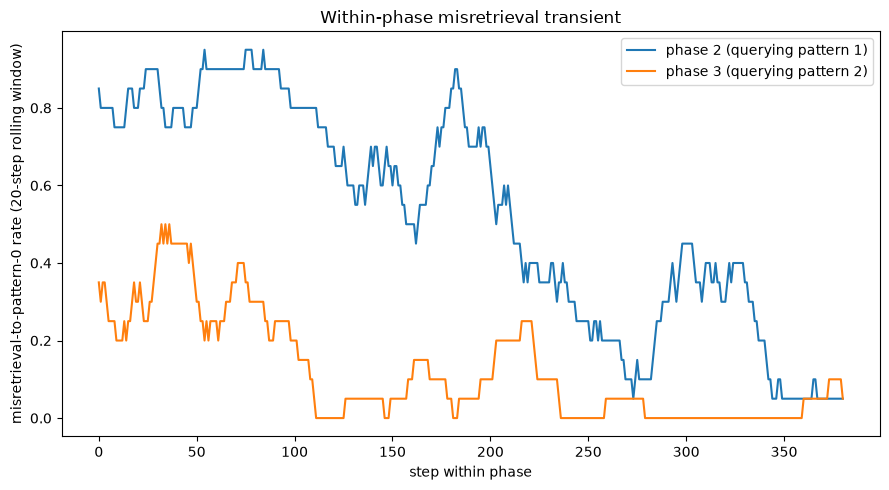

Phase 2: starts at 0.85, ends at 0.05, peak 0.95 at step 78
Phase 3: starts at 0.35, ends at 0.05, peak 0.50 at step 32


In [9]:
def windowed_misretrieval_rate(queried, won, phase_start, phase_end, window=20):
    q = queried[phase_start:phase_end].numpy()
    w = won[phase_start:phase_end].numpy()
    misretrieval = ((w == 0) & (q != 0)).astype(float)
    kernel = np.ones(window) / window
    return np.convolve(misretrieval, kernel, mode="valid")

phase2_rate = windowed_misretrieval_rate(run["queried"], run["won"], pb[1], pb[2])
phase3_rate = windowed_misretrieval_rate(run["queried"], run["won"], pb[2], pb[3])

plt.figure(figsize=(9, 5))
plt.plot(phase2_rate, label="phase 2 (querying pattern 1)")
plt.plot(phase3_rate, label="phase 3 (querying pattern 2)")
plt.xlabel("step within phase")
plt.ylabel("misretrieval-to-pattern-0 rate (20-step rolling window)")
plt.title("Within-phase misretrieval transient")
plt.legend()
plt.tight_layout()
plt.savefig("transient_within_phase.png", dpi=100)
plt.show()

print(f"Phase 2: starts at {phase2_rate[0]:.2f}, ends at {phase2_rate[-1]:.2f}, "
      f"peak {phase2_rate.max():.2f} at step {phase2_rate.argmax()}")
print(f"Phase 3: starts at {phase3_rate[0]:.2f}, ends at {phase3_rate[-1]:.2f}, "
      f"peak {phase3_rate.max():.2f} at step {phase3_rate.argmax()}")

## Task 2 (continued) — does the transient scale with phase length?

Re-run at phase_len=200 and phase_len=800 (same 4-phase pattern schedule, [0,1,2,0], no need
for phase 5 here), and compare the windowed phase-2 misretrieval curve both (a) in absolute
step count and (b) as a fraction of phase length. If curves line up in (a), the transient is a
roughly fixed-duration dynamical relaxation. If they line up in (b), it scales with phase
length instead.

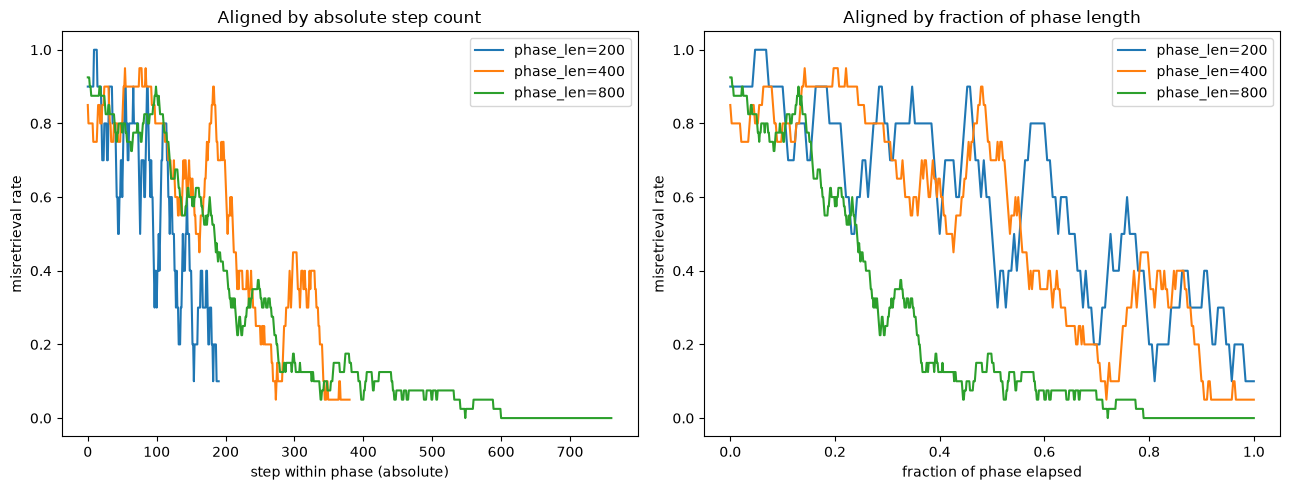

In [10]:
run_200 = run_two_layer_experiment(phase_len=200, phase_patterns=[0, 1, 2, 0], seed=0)
run_800 = run_two_layer_experiment(phase_len=800, phase_patterns=[0, 1, 2, 0], seed=0)

rate_200 = windowed_misretrieval_rate(run_200["queried"], run_200["won"],
                                       run_200["phase_bounds"][1], run_200["phase_bounds"][2], window=10)
rate_400 = windowed_misretrieval_rate(run["queried"], run["won"], pb[1], pb[2], window=20)
rate_800 = windowed_misretrieval_rate(run_800["queried"], run_800["won"],
                                       run_800["phase_bounds"][1], run_800["phase_bounds"][2], window=40)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(rate_200, label="phase_len=200")
axes[0].plot(rate_400, label="phase_len=400")
axes[0].plot(rate_800, label="phase_len=800")
axes[0].set_xlabel("step within phase (absolute)")
axes[0].set_ylabel("misretrieval rate")
axes[0].set_title("Aligned by absolute step count")
axes[0].legend()

axes[1].plot(np.linspace(0, 1, len(rate_200)), rate_200, label="phase_len=200")
axes[1].plot(np.linspace(0, 1, len(rate_400)), rate_400, label="phase_len=400")
axes[1].plot(np.linspace(0, 1, len(rate_800)), rate_800, label="phase_len=800")
axes[1].set_xlabel("fraction of phase elapsed")
axes[1].set_ylabel("misretrieval rate")
axes[1].set_title("Aligned by fraction of phase length")
axes[1].legend()

plt.tight_layout()
plt.savefig("transient_phase_length_scaling.png", dpi=100)
plt.show()

In [11]:
def first_step_below(rate, threshold=0.3):
    hits = np.nonzero(rate < threshold)[0]
    return int(hits[0]) if len(hits) > 0 else None

for name, rate, plen in [("200", rate_200, 200), ("400", rate_400, 400), ("800", rate_800, 800)]:
    step = first_step_below(rate)
    frac = step / plen if step is not None else None
    print(f"phase_len={plen}: first step below 30% misretrieval = {step} "
          f"(fraction of phase = {frac if frac is None else round(frac, 3)})")

phase_len=200: first step below 30% misretrieval = 132 (fraction of phase = 0.66)
phase_len=400: first step below 30% misretrieval = 244 (fraction of phase = 0.61)
phase_len=800: first step below 30% misretrieval = 215 (fraction of phase = 0.269)
